<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/DL/Text_Classification_with_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install transformers datasets scikit-learn

In [ ]:
# Load the dataset
from datasets import load_dataset

emotions = load_dataset("emotion", trust_remote_code=True)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
# Display the first example from the trainng set
emotions["train"][:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

In [ ]:
# Convert the Dataset to  Pandas Dataframe
import pandas as pd

# df = emotions["train"].to_pandas()
# df = pd.DataFrame(emotions["train"])
emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head(3)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3


In [ ]:
print(type(emotions["train"]))
print(emotions["train"].shape)



<class 'datasets.arrow_dataset.Dataset'>
(16000, 2)


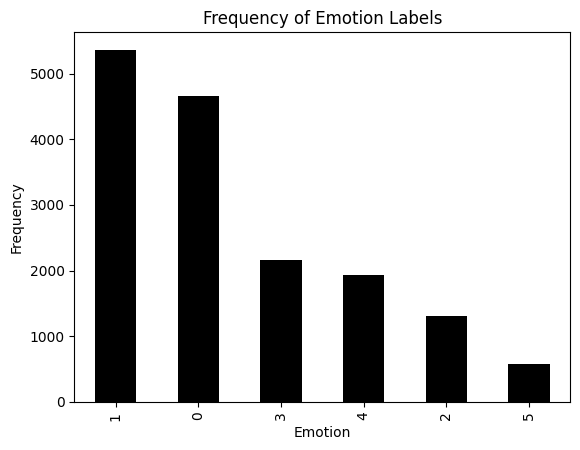

In [ ]:
# visualize the data
import matplotlib.pyplot as plt

#plot the distribution of emotion labels
df['label'].value_counts().plot(kind='bar', color = 'black')
plt.title('Frequency of Emotion Labels')
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.show()

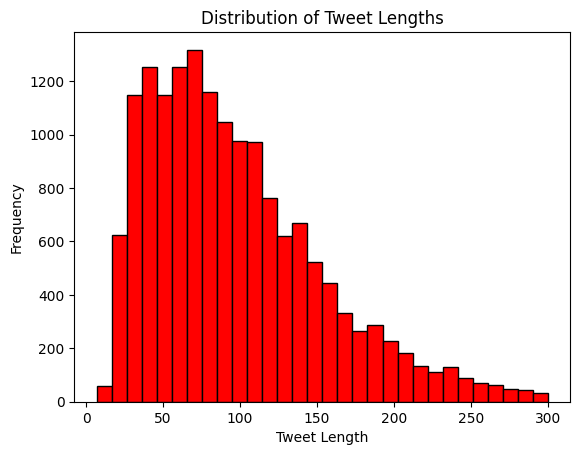

In [ ]:
# calculate tweet lengths

df['length'] = df['text'].apply(len)

#plot the distribution of tweet lengths
plt.hist(df['length'], bins=30, color='red', edgecolor='black')
plt.title('Distribution of Tweet Lengths')
plt.xlabel('Tweet Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# character tokenization example

text = 'hello world!'
tokens = list(text)
print(tokens)

['h', 'e', 'l', 'l', 'o', ' ', 'w', 'o', 'r', 'l', 'd', '!']


In [ ]:
# Example of word tokenization
import nltk # Natural Language Toolkit.
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

text = 'hello world!'
tokens = word_tokenize(text)
tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['hello', 'world', '!']

In [ ]:
# Example of subword tokenization
from transformers import AutoTokenizer # import the tokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased', force_download=True) # load the tokenizer
# Tokenize sample text
text = "unhappiness"
subword_tokens = tokenizer.tokenize(text)
subword_tokens

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

['un', '##ha', '##pp', '##iness']

In [ ]:
# Data processing

#example converting text to token
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
text  = 'Hello, how are you doing today?'
# text1  = 'Hello, Hello Hello Hello Hello Hello?'
tokens = tokenizer.tokenize(text)
tokens

['hello', ',', 'how', 'are', 'you', 'doing', 'today', '?']

In [ ]:
# convert token to Ids
input_ids = tokenizer.convert_tokens_to_ids(tokens)
input_ids

[7592, 1010, 2129, 2024, 2017, 2725, 2651, 1029]

In [ ]:
# Tokenize with padding and truncation

sentences = ["hello, how are you?", "I am fine, thank you!", "what about you?"]
encoding = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')#output হবে PyTorch tensor
print((encoding))

{'input_ids': tensor([[ 101, 7592, 1010, 2129, 2024, 2017, 1029,  102,    0],
        [ 101, 1045, 2572, 2986, 1010, 4067, 2017,  999,  102],
        [ 101, 2054, 2055, 2017, 1029,  102,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0, 0, 0]])}


In [ ]:
# Define Tokenization Function
def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True)

# Apply the tokenization Function to the Dataset
from datasets import load_dataset
emotions = load_dataset("emotion")
emotions_encoded = emotions.map(tokenize, batched=True)
print(emotions_encoded['train'][0])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'text': 'i didnt feel humiliated', 'label': 0, 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [ ]:
emotions["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [ ]:
! pip install datasets transformers

In [ ]:
#Example of using Transformers as Feature Extractions
import torch
from transformers import AutoTokenizer, AutoModel

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

#Define the function
def extract_features(text):
  inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
  output = model(**inputs)
  hidden_status = output.last_hidden_state

  #Use the[CLS] token hidden state as the featue representation
  cls_token_features = hidden_status[:, 0, :]
  return cls_token_features.detach().numpy()



model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
text = "Hello, how are you?"
feature = extract_features(text)
feature.shape

(1, 768)